In [1]:
import os
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

In [2]:
folder = "../Preprocessing-FeatureExtraction/cleaned-data/"
csv_files = glob.glob(os.path.join(folder, "*.csv"))

dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df['state'] = os.path.splitext(os.path.basename(file))[0] 
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
df = data.dropna()
df['sentiment'] = df['stars'].apply(lambda x: 0 if x <= 2 else (1 if x == 3 else 2))

print(f"Loaded {len(df)} reviews from {len(dfs)} states.")

Loaded 5222860 reviews from 20 states.


/var/folders/cl/5mfvhcls2nv2h9gy15m04b640000gn/T/ipykernel_7694/3678554632.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment'] = df['stars'].apply(lambda x: 0 if x <= 2 else (1 if x == 3 else 2))


In [14]:
sample_size = 500000
data_idx = df.sample(sample_size, random_state=42).index

# Build X (as a 2D array / DataFrame) and labels
X = df.loc[data_idx, ['clean_text', 'review_length', 'num_exclamations', 'num_caps_words']]
y_star = df.loc[data_idx, 'stars'].values
y_sent = df.loc[data_idx, 'sentiment'].values

# Single call to train_test_split to keep everything aligned
X_train, X_test, y_star_train, y_star_test, y_sent_train, y_sent_test = train_test_split(
    X, y_star, y_sent,
    test_size=0.10,
    random_state=42,
    stratify=y_star 
)

# Extract text and numeric columns separately
X_train_text = X_train['clean_text']
X_train_num = X_train.drop(columns=['clean_text']).astype(float)
X_test_text = X_test['clean_text']
X_test_num = X_test.drop(columns=['clean_text']).astype(float)

# TF-IDF on text
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

X_train_combined = hstack([X_train_tfidf, csr_matrix(X_train_num.values)])
X_test_combined  = hstack([X_test_tfidf,  csr_matrix(X_test_num.values)])

In [18]:
# --- 1. Train the regressor ---
regressor = Ridge()
regressor.fit(X_train_tfidf, y_star_train)

# --- 2. Predict continuous stars on the test set ---
y_pred_reg = regressor.predict(X_test_tfidf)

# --- 3. Convert to integer stars (1-5) ---
y_pred_class = np.clip(np.round(y_pred_reg), 1, 5).astype(int)

# --- 4. Evaluate ---
print("=== Classification Report (after rounding) ===")
print(classification_report(y_star_test, y_pred_class, digits=3))
print(f"Accuracy: {accuracy_score(y_star_test, y_pred_class):.4f}")

# --- Optional: regression metrics ---
from sklearn.metrics import mean_squared_error, mean_absolute_error
print(f"MAE: {mean_absolute_error(y_star_test, y_pred_reg):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_star_test, y_pred_reg)):.3f}")


=== Classification Report (after rounding) ===
              precision    recall  f1-score   support

         1.0      0.796     0.354     0.490      6055
         2.0      0.335     0.443     0.382      4186
         3.0      0.352     0.474     0.404      5605
         4.0      0.406     0.606     0.486     11892
         5.0      0.802     0.595     0.683     22262

    accuracy                          0.542     50000
   macro avg      0.539     0.494     0.489     50000
weighted avg      0.618     0.542     0.556     50000

Accuracy: 0.5420
MAE: 0.584
RMSE: 0.749


<Figure size 640x480 with 0 Axes>

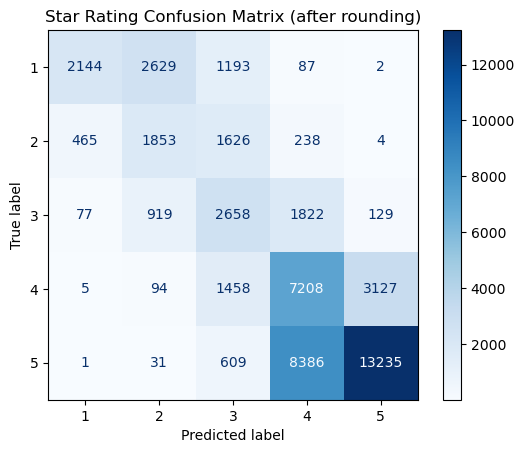

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig = plt.figure()
cm = confusion_matrix(y_star_test, y_pred_class, labels=[1,2,3,4,5])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4,5])
disp.plot(cmap='Blues')
plt.title("Star Rating Confusion Matrix (after rounding)")
plt.show()


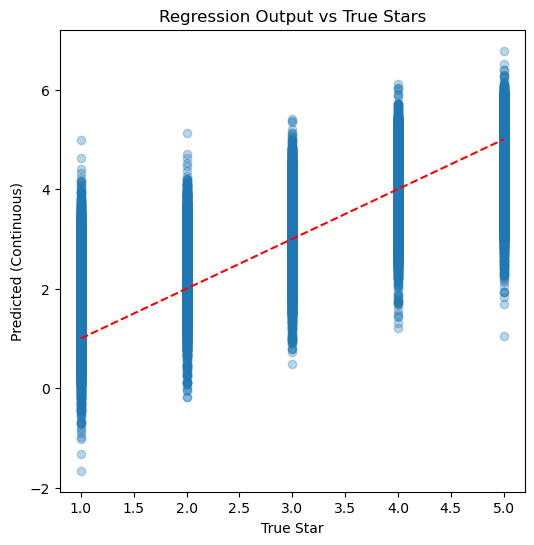

In [20]:
plt.figure(figsize=(6,6))
plt.scatter(y_star_test, y_pred_reg, alpha=0.3)
plt.plot([1,5],[1,5], 'r--')  # ideal diagonal
plt.xlabel('True Star')
plt.ylabel('Predicted (Continuous)')
plt.title('Regression Output vs True Stars')
plt.show()
